In [20]:
import numpy as np 
import pandas as pd

In [21]:
df = pd.read_csv("adult.csv")
# Purpose: To predict how many people have <50k and >50k income with their personal and professional details

In [22]:
# Step 1: Understanding of data
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [24]:
df.sample(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
17464,32,Private,202952,HS-grad,9,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,<=50K
6810,34,Private,442656,11th,7,Never-married,Sales,Unmarried,White,Female,0,0,65,Guatemala,<=50K
33567,59,Self-emp-inc,31359,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,15024,0,80,United-States,>50K
39422,36,Private,89718,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,40,United-States,<=50K
13013,48,Private,120902,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,>50K


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [26]:
# Step 2: Drop columns that are not usefull
df.drop(columns=["fnlwgt","education","relationship","native-country", "race"], inplace=True)       

In [27]:
df.info

<bound method DataFrame.info of        age     workclass  educational-num      marital-status  \
0       25       Private                7       Never-married   
1       38       Private                9  Married-civ-spouse   
2       28     Local-gov               12  Married-civ-spouse   
3       44       Private               10  Married-civ-spouse   
4       18             ?               10       Never-married   
...    ...           ...              ...                 ...   
48837   27       Private               12  Married-civ-spouse   
48838   40       Private                9  Married-civ-spouse   
48839   58       Private                9             Widowed   
48840   22       Private                9       Never-married   
48841   52  Self-emp-inc                9  Married-civ-spouse   

              occupation  gender  capital-gain  capital-loss  hours-per-week  \
0      Machine-op-inspct    Male             0             0              40   
1        Farming-fishing   

In [28]:
#Step 3: Check duplicates and then remove them
print("Duplicates:", df.duplicated().sum())

Duplicates: 10511


In [29]:
# As this dataset contain alot of duplicates , so remove them
df = df.drop_duplicates()

In [30]:
#Step 4: Check null values, if have remove them
print(df.isnull().sum())

age                0
workclass          0
educational-num    0
marital-status     0
occupation         0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
income             0
dtype: int64


In [31]:
import matplotlib.pyplot as plt

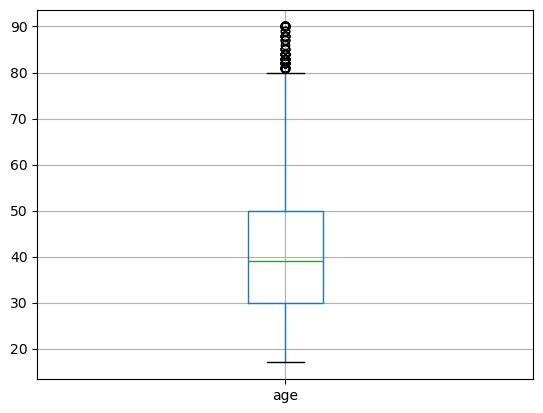

In [32]:
# Step 5: Check outliers on numeric column first
df.boxplot(column="age")
plt.show()

In [33]:
# Interquartile Range method: use to detect and remove outliers
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df["age"] < (Q1 - 1.5 * IQR)) |
         (df["age"] < (Q1 - 1.5 * IQR)))]
print("Shape after outlier remove: ", df.shape)

Shape after outlier remove:  (38331, 10)


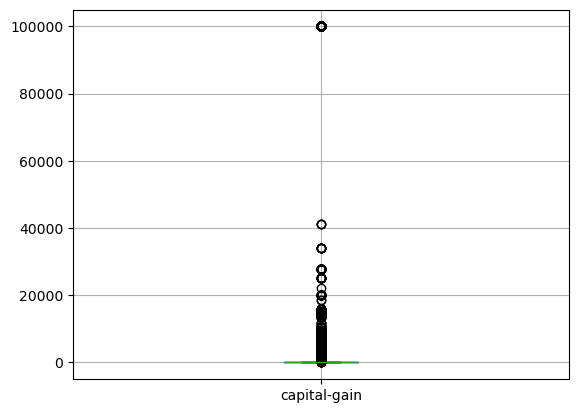

In [34]:
# Check outlier of other numeric columns
df.boxplot(column="capital-gain")
plt.show()

In [35]:
Q1 = df["capital-gain"].quantile(0.25)
Q3 = df["capital-gain"].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df["capital-gain"] < (Q1 - 1.5 * IQR)) |
         (df["capital-gain"] < (Q1 - 1.5 * IQR)))]
print("Shape after outlier remove: ", df.shape)

Shape after outlier remove:  (38331, 10)


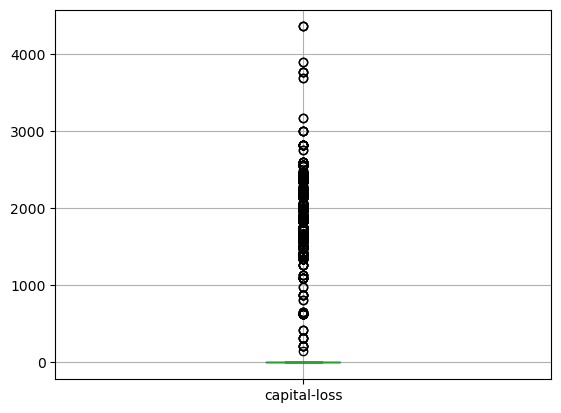

In [36]:
df.boxplot(column="capital-loss")
plt.show()

In [37]:
Q1 = df["capital-loss"].quantile(0.25)
Q3 = df["capital-loss"].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df["capital-loss"] < (Q1 - 1.5 * IQR)) |
         (df["capital-loss"] < (Q1 - 1.5 * IQR)))]
print("Shape after outlier remove: ", df.shape)

Shape after outlier remove:  (38331, 10)


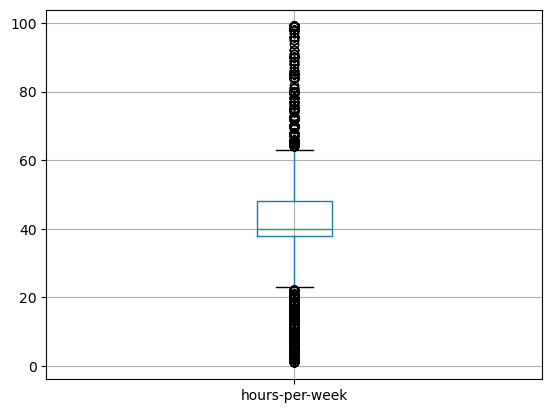

In [38]:
df.boxplot(column="hours-per-week")
plt.show()

In [39]:
Q1 = df["hours-per-week"].quantile(0.25)
Q3 = df["hours-per-week"].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df["hours-per-week"] < (Q1 - 1.5 * IQR)) |
         (df["hours-per-week"] < (Q1 - 1.5 * IQR)))]
print("Shape after outlier remove: ", df.shape)

Shape after outlier remove:  (34559, 10)


In [ ]:
#Step 6: Apply Encoding on categorical data
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
import pandas as pd

# Label Encoding: Apply on Binary Columns (2 values only)
# Gender column, Income column
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])
df["income"] = le.fit_transform(df["income"])

# OneHot Encoding: Apply on Nominal Columns (No Order/Categories have no ranking)
# Workclass column
ohe_workclass = OneHotEncoder(sparse_output=False , drop="first")
encoded_workclass = ohe_workclass.fit_transform(df[["workclass"]])

encoded_workclass_df = pd.DataFrame(encoded_workclass,
                                    columns=ohe_workclass.get_feature_names_out(["workclass"]),
                                    index=df.index)
df = pd.concat([df, encoded_workclass_df], axis=1)
df.drop(columns=["workclass"], inplace=True)

# Occupation column
ohe_occupation = OneHotEncoder(sparse_output=False , drop="first")
encoded_occupation = ohe_occupation.fit_transform(df[["occupation"]])

encoded_occupation_df = pd.DataFrame(encoded_occupation,
                                    columns=ohe_occupation.get_feature_names_out(["occupation"]),
                                    index=df.index)
df = pd.concat([df, encoded_occupation_df], axis=1)
df.drop(columns=["occupation"], inplace=True)

# Ordinal Encoding: Apply on Ordinal Columns (Have Order/Categories have meaningful ranking)
oe = OrdinalEncoder(categories=[[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]])
df[["educational-num"]] = oe.fit_transform(df[["educational-num"]])

print(df.head())
print(df.shape)
print(df.info())